---
title: "Exploratory Data Analysis"
format:
    html: 
        code-fold: false
---

<!-- After digesting the instructions, you can delete this cell, these are assignment instructions and do not need to be included in your final submission.  -->

{{< include instructions.qmd >}} 

## Analyze Messi's playing style

Summarize Lionel Messi's playing style using ChatGPT

This script read the file containing Lionel Messi’s style and then use OpenAI’s gpt-5-nano model to automatically analyze and summarize it. The analysis focuses on Messi’s core strengths, technical skills, tactical evolution, and infulence. The output includes a structured summary and a set of 15 keywords or short phrases that can summarize his playing style.


In [1]:
from openai import OpenAI
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ks_2samp, ttest_ind, chi2_contingency, f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd


In [2]:
# Analyze Messi's playing style: load profile JSON, prompt GPT-5-nano to summarize key traits,
# tactical evolution, strengths, and list 15 words/phrases representing his style.
with open('/Users/hanmingyang/.api-keys.json') as f:
    keys = json.load(f)
API_KEY = keys['openai_api_key']


client = OpenAI(api_key=API_KEY)


with open('../../data/raw-data/Lionel_Messi_Player_Profile.json', 'r', encoding='utf-8') as f:
    messi_data = json.load(f)


if isinstance(messi_data, (dict, list)):
    messi_text = json.dumps(messi_data, ensure_ascii=False, indent=2)
else:
    messi_text = str(messi_data)

# the command prompt
prompt = f""" 
You are a football analyst. Analyze and summarize the following detailed description of Lionel Messi’s playing style.

Your task:
1. Provide a well-structured summary (around 200–250 words) highlighting his main strengths, tactical evolution, technical traits, and influence.
2. Then, list **15 single words or short phrases** that best represent his overall style and identity as a footballer. These should include technical, tactical, and psychological aspects.
3. Make the summary objective, professional, and neutral in tone.

Here is the text to analyze:
{messi_text}
"""


response = client.responses.create(
    model="gpt-5-nano",  
    input=prompt,
)
print("\n--- Summary ---\n")
print(response.output_text)



--- Summary ---

Summary (approximately 222 words)

Messi’s playing style blends exceptional technical gifts with sophisticated tactical intelligence. His short stature and low center of gravity grant him remarkable balance and agility, enabling rapid direction changes and effective evasion of tackles. Strong upper‑body balance complements quick feet, supporting short bursts of acceleration while maintaining close ball control. Predominantly left‑footed, he often starts dribble runs with the outside of his left foot and finishes or serves passes with the inside. He is a prolific scorer—combining precise finishing, intelligent positioning, rapid reactions, and repeated attacking runs to break lines—and a world‑class playmaker, with vision and a broad passing range.

Over time, Messi evolved from a winger and early playmaker into a deeper orchestrator who can dictate play from central zones. He has functioned as a false nine, a central striker, and a free creative midfielder, roaming to

This part of the code shows the awards and championships Messi has won, sorts them into team and individual categories, and draws bar charts to display the number of each type of award.

In [3]:
df = pd.read_csv('../../data/raw-data/honor.csv')
df.head()

,Club/National Team,Competition / Award,Years,Type,Count
0,Barcelona,La Liga,"2004–05, 2005–06, 2008–09, 2009–10, 2010–11, 2...",Team,10
1,Barcelona,Copa del Rey,"2008–09, 2011–12, 2014–15, 2015–16, 2016–17, 2...",Team,7
2,Barcelona,Supercopa de España,"2006, 2009, 2010, 2011, 2013, 2016, 2018",Team,7
3,Barcelona,UEFA Champions League,"2005–06, 2008–09, 2010–11, 2014–15",Team,4
4,Barcelona,UEFA Super Cup,"2009, 2011, 2015",Team,3


## Plot Messi's awards

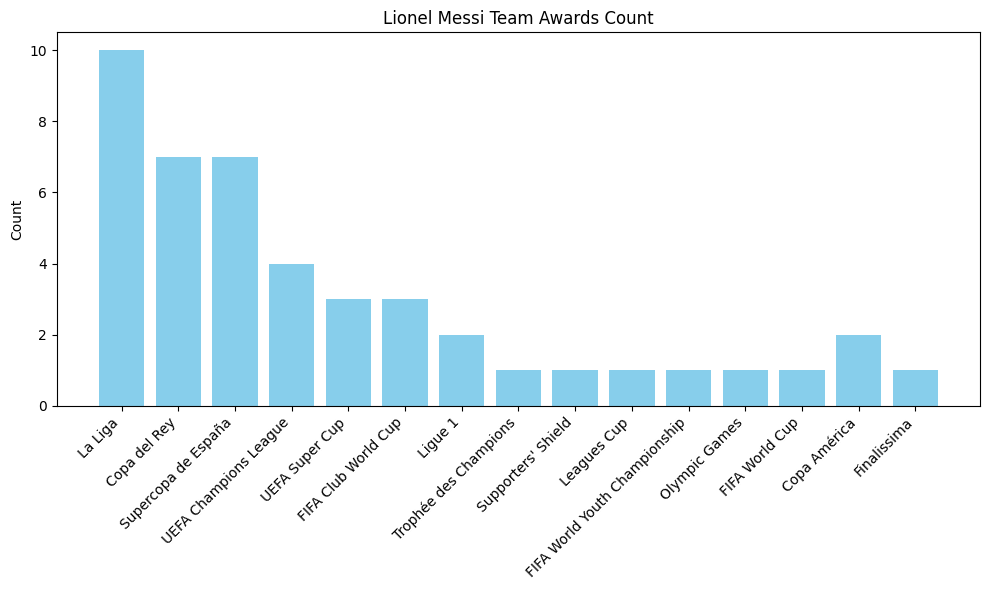

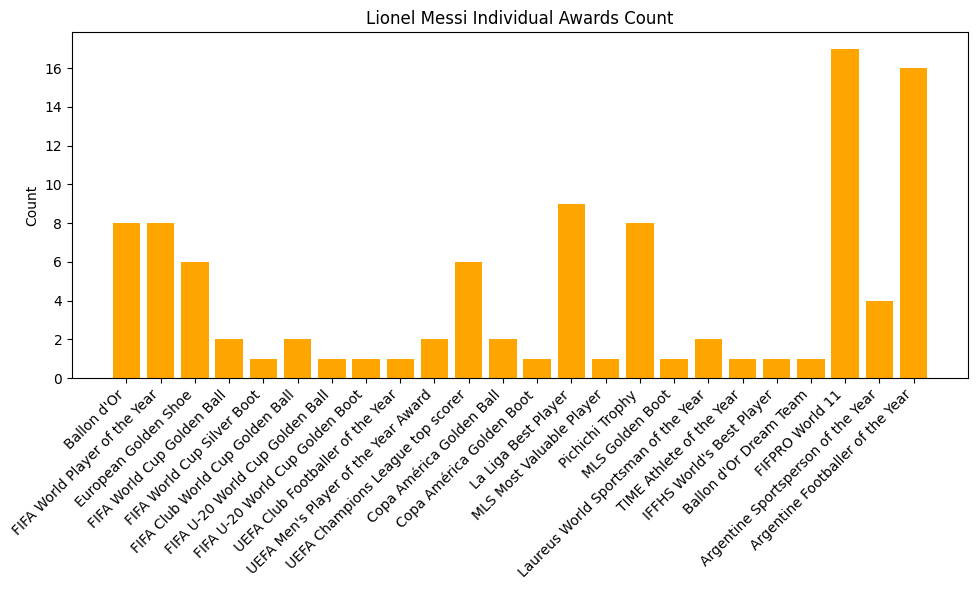

In [4]:
# Plot Messi's awards: separate team and individual awards, then create bar charts
team_df = df[df['Type'] == 'Team']
individual_df = df[df['Type'] == 'Individual']

plt.figure(figsize=(10,6))
plt.bar(team_df['Competition / Award'], team_df['Count'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title('Lionel Messi Team Awards Count')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
plt.bar(individual_df['Competition / Award'], individual_df['Count'], color='orange')
plt.xticks(rotation=45, ha='right')
plt.title('Lionel Messi Individual Awards Count')
plt.ylabel('Count')
plt.tight_layout()

plt.show()

## Lionel Messi Honors and Achievements

### Club Achievements
- **Barcelona:** 10 × La Liga, 7 × Copa del Rey, 7 × Supercopa de España, 4 × UEFA Champions League, 3 × UEFA Super Cup, 3 × FIFA Club World Cup  
- **Paris Saint-Germain:** 2 × Ligue 1, 1 × Trophée des Champions  
- **Inter Miami:** one Supporters' Shield, one Leagues Cup  

### International Honors 
- **Argentina:** FIFA World Cup (2022)(GOAT), Copa América (2021, 2024), Finalissima (2022) 
This World Cup has left no regrets in Messi's career.

### Individual Accolades
- **Ballon d’Or:** 8 times (2009 - 2012(Four consecutive Ballon d'Or awards, unique in history), 2015, 2019, 2021, 2023) (most in history) 
- **FIFPRO World XI:** 17 selections (2007–2023)  
- **FIFA World Player of the Year:** 8 times  
- **FIFA World Cup Golden Ball:** 2 times (2014, 2022)  
- **FIFA Club World Cup Golden Ball:** 2 times 
- **European Golden Shoe:** 6 times  (most in history) 
- **UEFA Club Footballer of the Year & UEFA Men’s Player of the Year:** Multiple seasons  
- **La Liga Pichichi Trophy:** Multiple seasons  
- **Laureus World Sportsman of the Year:** 2020, 2023 (first footballer to win)


Messi’s honors demonstrate his technical mastery, consistency, and global recognition, underscoring his status as one of football’s greatest players.



In [5]:
club_data = pd.read_csv('../../data/processed-data/messi_club_career_clean.csv')
national_data = pd.read_csv('../../data/processed-data/messi_national_career_clean.csv')
detailed_data = pd.read_csv('../../data/processed-data/messi_club_detailed_cleaned.csv')
position = pd.read_csv('../../data/raw-data/position.csv')

## Visualize Messi's efficiency

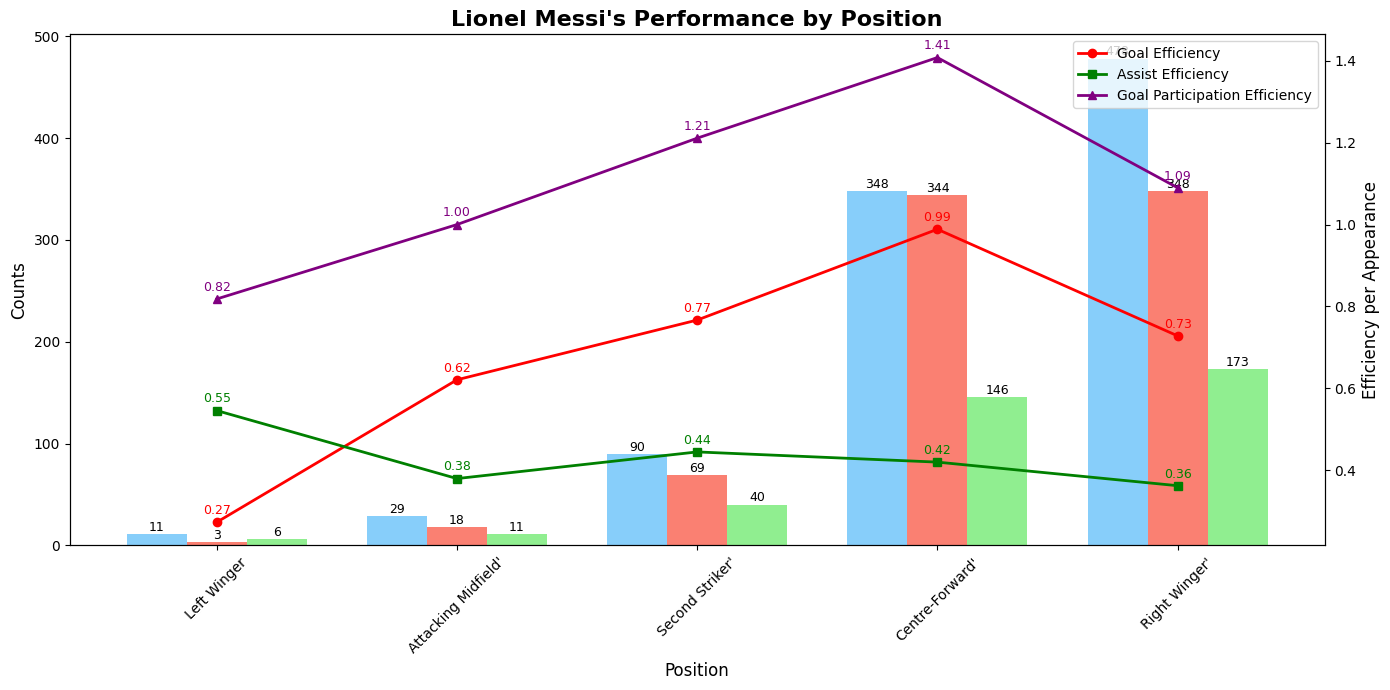

In [ ]:
# Extract relevant performance data by position
x = position['Position']
appearances = position['Appearances']
goals = position['Goals']
assists = position['Assists']

# Calculate efficiency metrics per appearance
goal_efficiency = goals / appearances
assist_efficiency = assists / appearances
goal_participation_efficiency = (goals + assists) / appearances

# Set bar width and x-axis positions
width = 0.25
x_indices = np.arange(len(x))

plt.figure(figsize=(14,7))

# Plot bars: appearances, goals, and assists
bars1 = plt.bar(x_indices - width, appearances, width=width, color='#87CEFA')
bars2 = plt.bar(x_indices, goals, width=width, color='#FA8072')
bars3 = plt.bar(x_indices + width, assists, width=width, color='#90EE90')

# Add value labels on bars
for bar in [bars1, bars2, bars3]:
    for rect in bar:
        height = rect.get_height()
        plt.text(rect.get_x() + rect.get_width()/2, height + 0.2, f'{int(height)}', ha='center', va='bottom', fontsize=9)

plt.xlabel('Position', fontsize=12)
plt.ylabel('Counts', fontsize=12)
plt.xticks(ticks=x_indices, labels=x, rotation=45)

# Create twin y-axis for efficiency line plots
plt2 = plt.twinx()

# Plot efficiency metrics
line1, = plt2.plot(x_indices, goal_efficiency, label='Goal Efficiency', color='red', marker='o', linewidth=2)
line2, = plt2.plot(x_indices, assist_efficiency, label='Assist Efficiency', color='green', marker='s', linewidth=2)
line3, = plt2.plot(x_indices, goal_participation_efficiency, label='Goal Participation Efficiency', color='purple', marker='^', linewidth=2)
plt2.set_ylabel('Efficiency per Appearance', fontsize=12)

# Add value labels for line plots
for i, val in enumerate(goal_efficiency):
    plt2.text(i, val + 0.02, f'{val:.2f}', ha='center', color='red', fontsize=9)
for i, val in enumerate(assist_efficiency):
    plt2.text(i, val + 0.02, f'{val:.2f}', ha='center', color='green', fontsize=9)
for i, val in enumerate(goal_participation_efficiency):
    plt2.text(i, val + 0.02, f'{val:.2f}', ha='center', color='purple', fontsize=9)

# Set title
plt.title("Lionel Messi's Performance by Position", fontsize=16, fontweight='bold')

# Manually create legend handles for bars
bar_handles = [plt.Rectangle((0,0),1,1,color=c) for c in ['#87CEFA','#FA8072','#90EE90']]
bar_labels = ['Appearances','Goals','Assists']

# Combine legends for bars and lines
plt.legend(handles=bar_handles, labels=bar_labels, loc='upper left', fontsize=10)  
plt2.legend(handles=[line1,line2,line3], loc='upper right', fontsize=10)           

plt.tight_layout()
plt.show()


From the charts, it is clear that Messi shows a high level of performance in all attacking positions. As a center forward or false nine(second-striker), he can goal in almost every match. Even when playing as left or right winger or as an attacking midfielder, his per-game contributions approach or exceed one goal involvement. it shows his comprehensive attacking ability.

Right wing is Messi’s best position, he scored 478 goals and made 173 assists in over 400 appearances. As a center forward, his efficiency is even higher, with his per-game goal contribution reaching the peak of his career.

## Visualize Messi's appearance

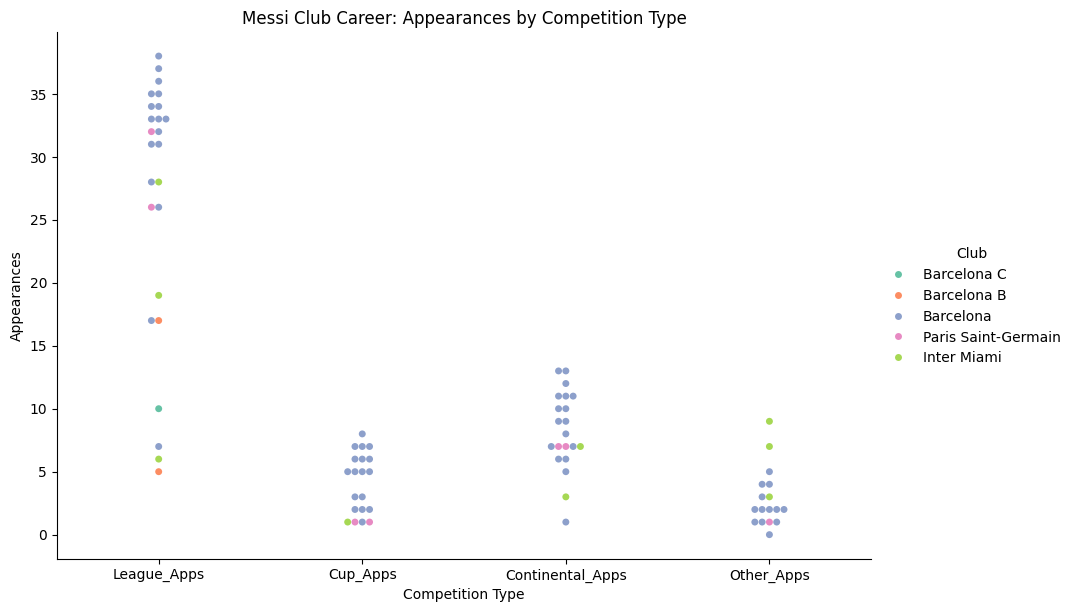

In [7]:
# Remove total rows from club and national datasets
club_data_no_total = club_data.iloc[:-1]
national_data_no_total = national_data.iloc[:-1]

# Reshape club data to long format for plotting
club_long = club_data_no_total.melt(
    id_vars=['Club', 'Season'],
    value_vars=['League_Apps', 'Cup_Apps', 'Continental_Apps', 'Other_Apps'],
    var_name='Competition_Type',
    value_name='Appearances'
)

# Plot appearances by competition type using a swarm plot
sns.catplot(
    data=club_long,
    kind="swarm",
    x="Competition_Type",
    y="Appearances",
    hue="Club",
    palette="Set2",
    height=6,
    aspect=1.5
)

plt.title("Messi Club Career: Appearances by Competition Type")
plt.xlabel("Competition Type")
plt.ylabel("Appearances")
plt.show()



According to the statistics of the club's career statistics on the number of appearances, Messi had the most appearances in the league, followed by domestic matches and cup competitions. During his time at Barcelona, Messi's number of appearances was particularly stable and high, indicating that he was the core player of the club. His main contributions were concentrated in the league and important international events. At the same time, his performance in terms of the number of appearances also demonstrated his long-term high stability.

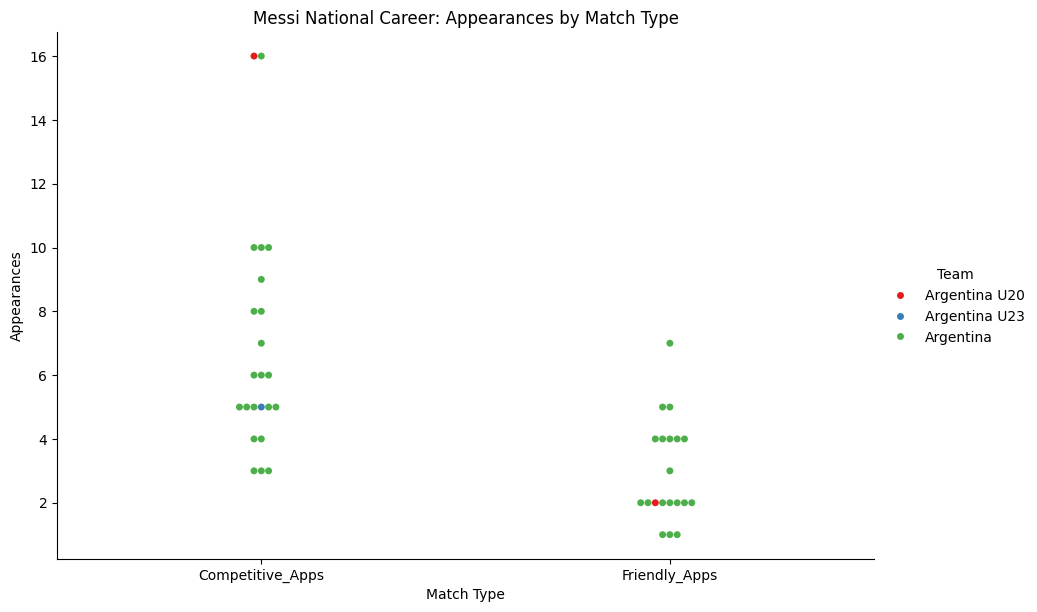

In [8]:
df_plot = national_data_no_total[['Year', 'Team', 'Competitive_Apps', 'Friendly_Apps']]

national_long = national_data_no_total.melt(
    id_vars=['Team', 'Year'],
    value_vars=['Competitive_Apps', 'Friendly_Apps'],
    var_name='Match_Type',   
    value_name='Appearances' 
)

sns.catplot(
    data=national_long,
    kind="swarm",
    x="Match_Type",     
    y="Appearances",    
    hue="Team",         
    palette="Set1",
    height=6,
    aspect=1.5
)

plt.title("Messi National Career: Appearances by Match Type")
plt.xlabel("Match Type")
plt.ylabel("Appearances")
plt.show()



From the statistics of Messi's appearances for the international team, it can be seen that his number of appearances in official matches is generally higher than that in friendly matches. Friendly matches have relatively fewer appearances and are more scattered in terms of distribution. This indicates that Messi mainly exerting his influence in important competitions.

## The impact of penalty kicks on goals scored

/var/folders/fd/zfxd46k90qd0bd_xk04w45r40000gn/T/ipykernel_86728/3353254595.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=penalty_true, x="Current Club", y="goals_overall", palette="Set2")


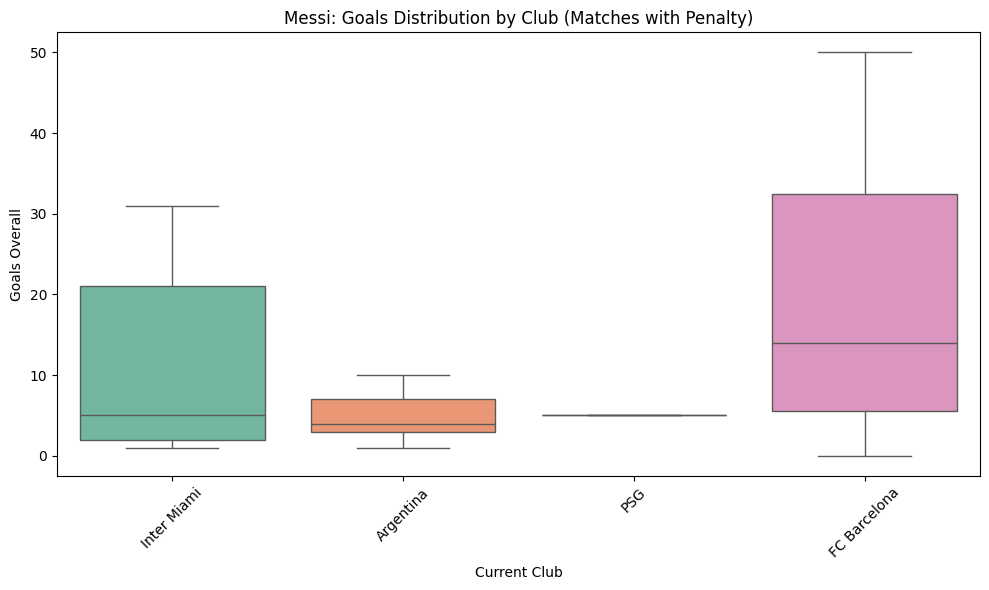

/var/folders/fd/zfxd46k90qd0bd_xk04w45r40000gn/T/ipykernel_86728/3353254595.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=penalty_false, x="Current Club", y="goals_overall", palette="Set2")


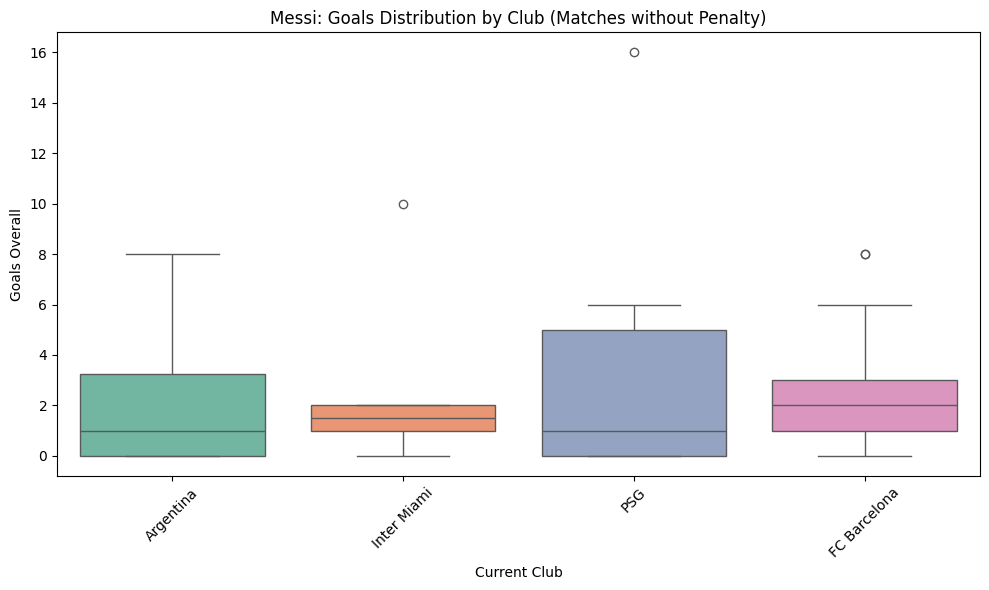

In [9]:
# Filter data by penalty status
penalty_true = detailed_data[detailed_data['has_penalty'] == True]
penalty_false = detailed_data[detailed_data['has_penalty'] == False]

# Plot for matches with penalties
plt.figure(figsize=(10,6))
sns.boxplot(data=penalty_true, x="Current Club", y="goals_overall", palette="Set2")
plt.title("Messi: Goals Distribution by Club (Matches with Penalty)")
plt.xlabel("Current Club")
plt.ylabel("Goals Overall")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot for matches without penalties
plt.figure(figsize=(10,6))
sns.boxplot(data=penalty_false, x="Current Club", y="goals_overall", palette="Set2")
plt.title("Messi: Goals Distribution by Club (Matches without Penalty)")
plt.xlabel("Current Club")
plt.ylabel("Goals Overall")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


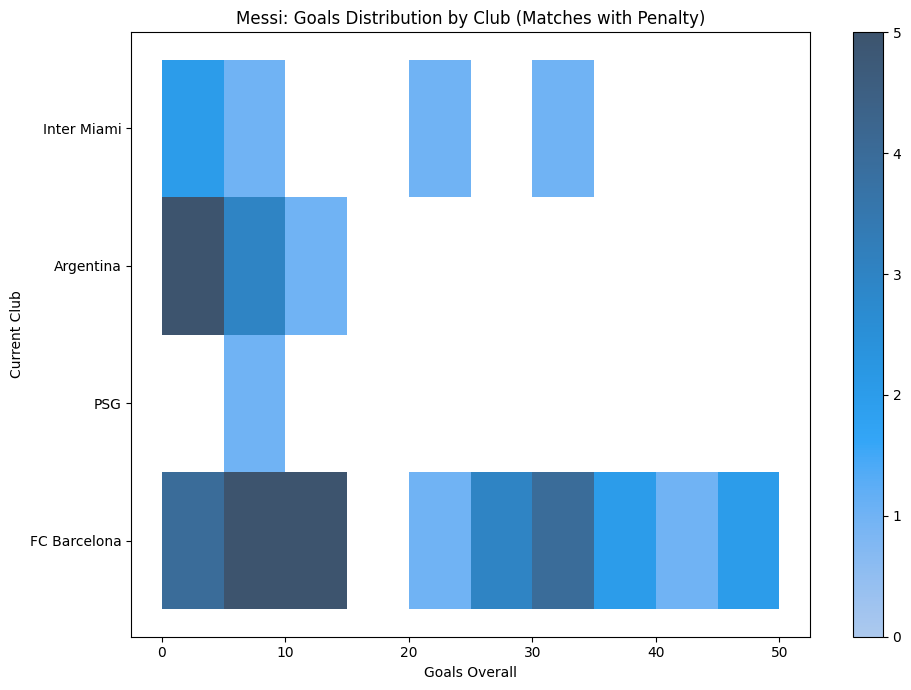

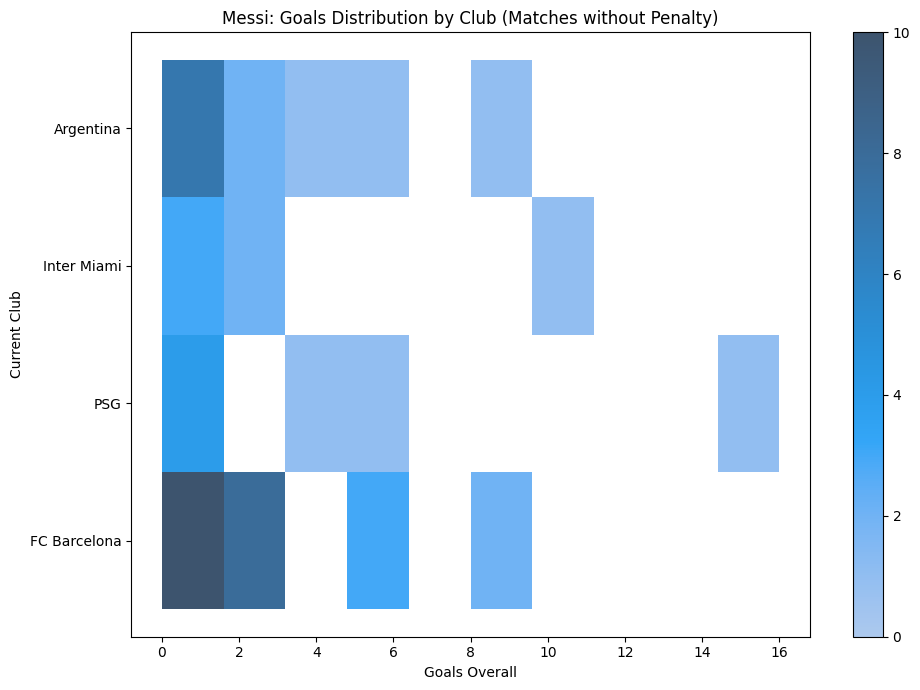

In [10]:
# Split data by penalty status
penalty_true = detailed_data[detailed_data['has_penalty'] == True]
penalty_false = detailed_data[detailed_data['has_penalty'] == False]

# Plot goal distribution for matches with penalties
plt.figure(figsize=(10,7))
sns.histplot(data=penalty_true, x="goals_overall", y="Current Club", bins=10, cbar=True)
plt.title("Messi: Goals Distribution by Club (Matches with Penalty)")
plt.xlabel("Goals Overall")
plt.ylabel("Current Club")
plt.tight_layout()
plt.show()

# Plot goal distribution for matches without penalties
plt.figure(figsize=(10,7))
sns.histplot(data=penalty_false, x="goals_overall", y="Current Club", bins=10, cbar=True)
plt.title("Messi: Goals Distribution by Club (Matches without Penalty)")
plt.xlabel("Goals Overall")
plt.ylabel("Current Club")
plt.tight_layout()
plt.show()


From these boxplots, it can be seen that Messi's number of goals in games with penalties was higher, indicating that penalties made an additional contribution to his total goals. This is expected since penalties provide a direct scoring opportunity. However, even in games without penalties, Messi still maintained a significant number of goals, showcasing his ability to score through open play and other situations.

## Yellow cards and red cards

/var/folders/fd/zfxd46k90qd0bd_xk04w45r40000gn/T/ipykernel_86728/1468143200.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(


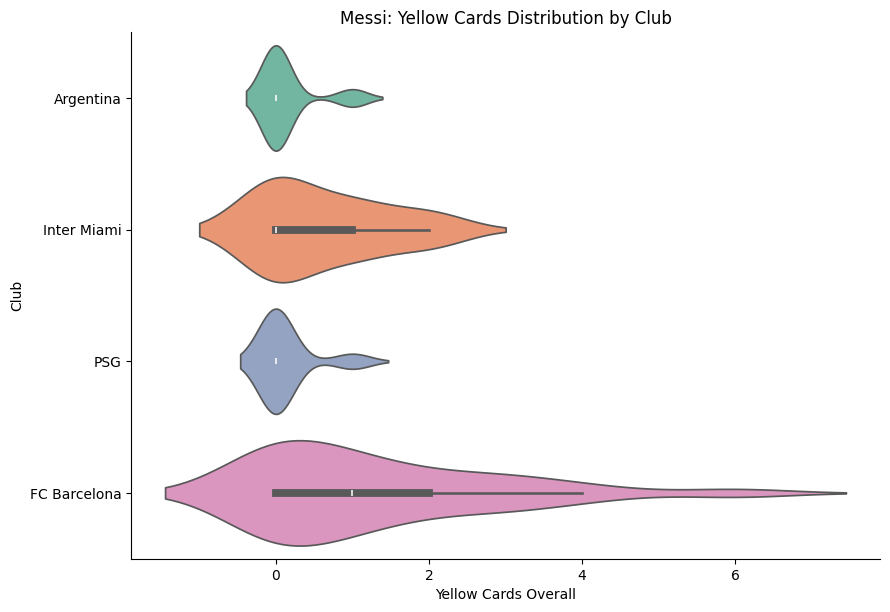

/var/folders/fd/zfxd46k90qd0bd_xk04w45r40000gn/T/ipykernel_86728/1468143200.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(


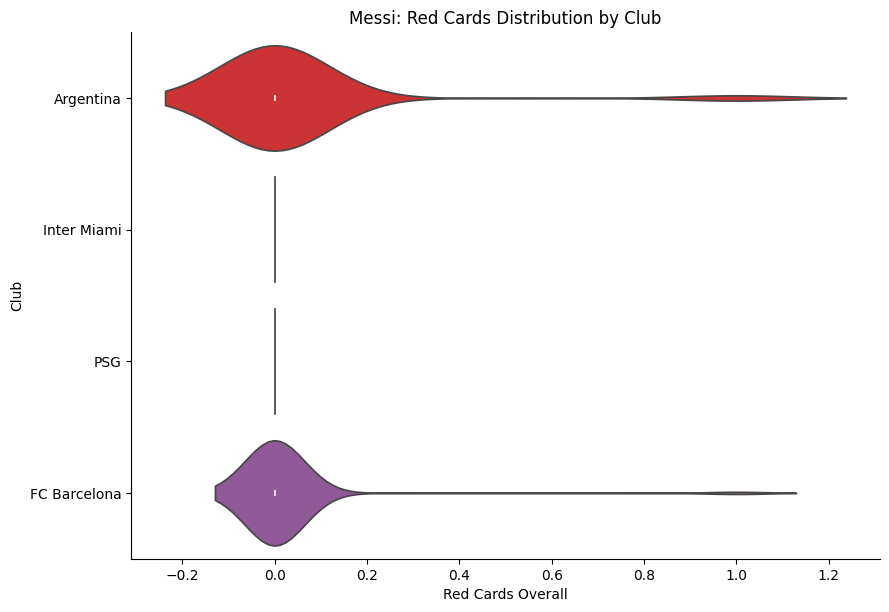

In [ ]:
# Violin plot for yellow cards distribution by club
sns.catplot(
    data=detailed_data,
    kind="violin",                # Violin plot shows distribution shape
    x="yellow_cards_overall",      # X-axis: total yellow cards
    y="Current Club",              # Y-axis: club
    height=6,
    aspect=1.5,
    palette="Set2"                 
)
plt.title("Messi: Yellow Cards Distribution by Club")
plt.xlabel("Yellow Cards Overall")
plt.ylabel("Club")
plt.show()

# Violin plot for red cards distribution by club
sns.catplot(
    data=detailed_data,
    kind="violin",                 # Violin plot shows distribution shape
    x="red_cards_overall",         # X-axis: total red cards
    y="Current Club",              # Y-axis: club
    height=6,
    aspect=1.5,
    palette="Set1"               
)
plt.title("Messi: Red Cards Distribution by Club")
plt.xlabel("Red Cards Overall")
plt.ylabel("Club")
plt.show()


Messi receives very few yellow cards in club matches, and the numbers are consistent, showing he rarely gets cautioned. Red cards are even rarer, almost zero, meaning he hardly ever commits serious fouls or gets sent off. Overall, Messi plays cleanly and disciplined, is very skilled, and highly professional, which is why he is widely respected

## Goals vs appearances by club

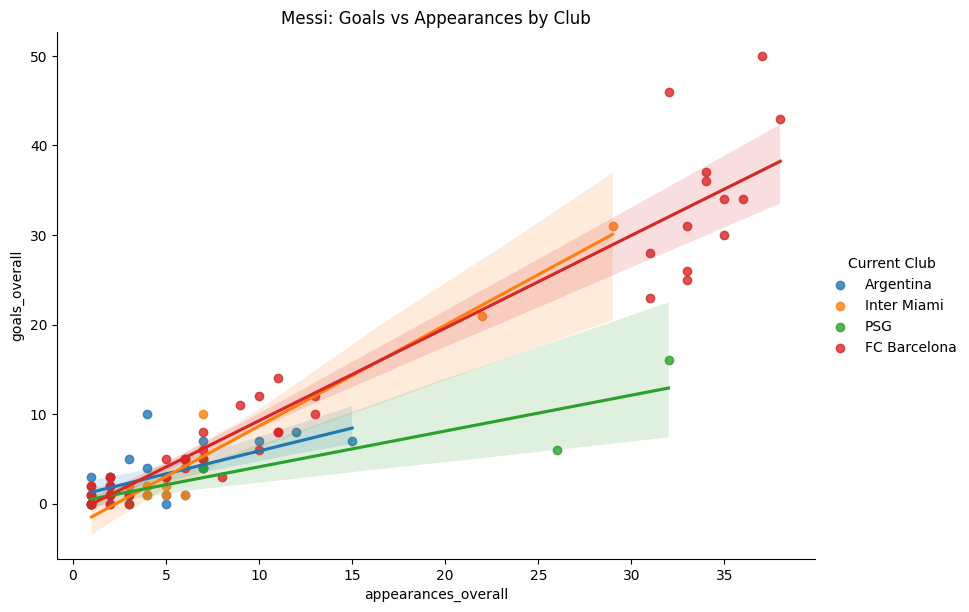

In [12]:
# Scatter plot with regression lines: goals vs appearances by club
sns.lmplot(
    data=detailed_data,
    x="appearances_overall",  # X-axis: total appearances
    y="goals_overall",        # Y-axis: total goals
    hue="Current Club",       # Different clubs shown in different colors
    height=6,
    aspect=1.4
)

# Set plot title
plt.title("Messi: Goals vs Appearances by Club")

# Show the plot
plt.show()


As can be seen from the graph, the total number of goals scored by Messi across all clubs generally increases with the increase in the number of appearances, showing a roughly linear trend. Among them, Messi's goal-scoring efficiency was the highest at Inter Miami, followed by Barcelona, while it was the lowest at Paris Saint-Germain. This was mainly because the tactical core of Paris Saint-Germain was Mbappé rather than Messi. However, considering the intensity of the MLS games and Messi's age, his performance at Barcelona can still be regarded as the peak of his club career.

## Visualize relationships between metrics

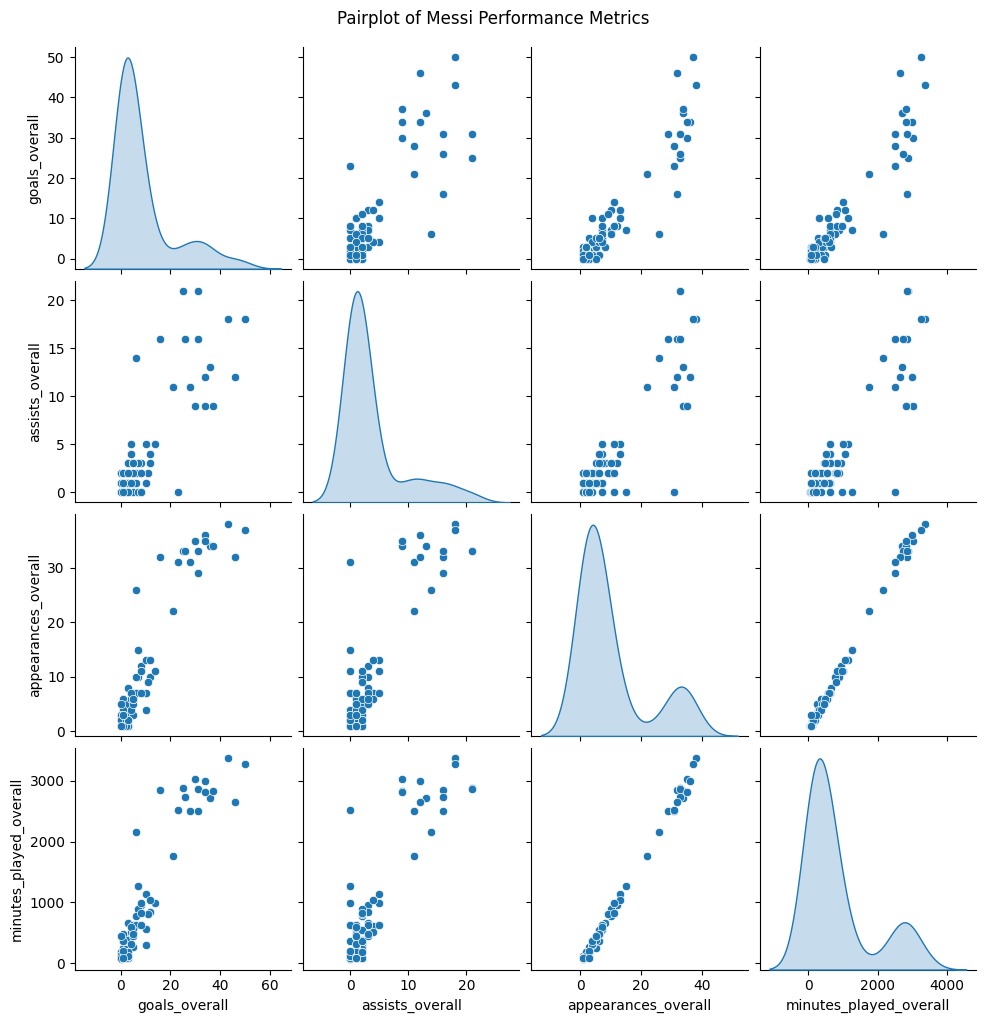

In [13]:
# Select key performance metrics
cols = ['goals_overall', 'assists_overall', 'appearances_overall', 'minutes_played_overall']

# Create a pairplot to visualize relationships between metrics
sns.pairplot(
    detailed_data[cols],
    diag_kind='kde',  # Use KDE plot on the diagonal to show distributions
    kind='scatter'    # Scatter plots for off-diagonal pairwise relationships
)

# Set overall title for the plot
plt.suptitle("Pairplot of Messi Performance Metrics", y=1.02)

# Display the plot
plt.show()


As can be seen from the graph, Messi's total playing time (minutes_played_overall) and total appearances (appearances_overall) are significantly positively correlated with his total goals (goals_overall) and total assists (assists_overall), indicating that the more he plays or the longer he plays, the higher his goal and assist output will be. There is also a certain positive correlation between the number of goals and assists, reflecting Messi's comprehensive offensive contribution in the game.

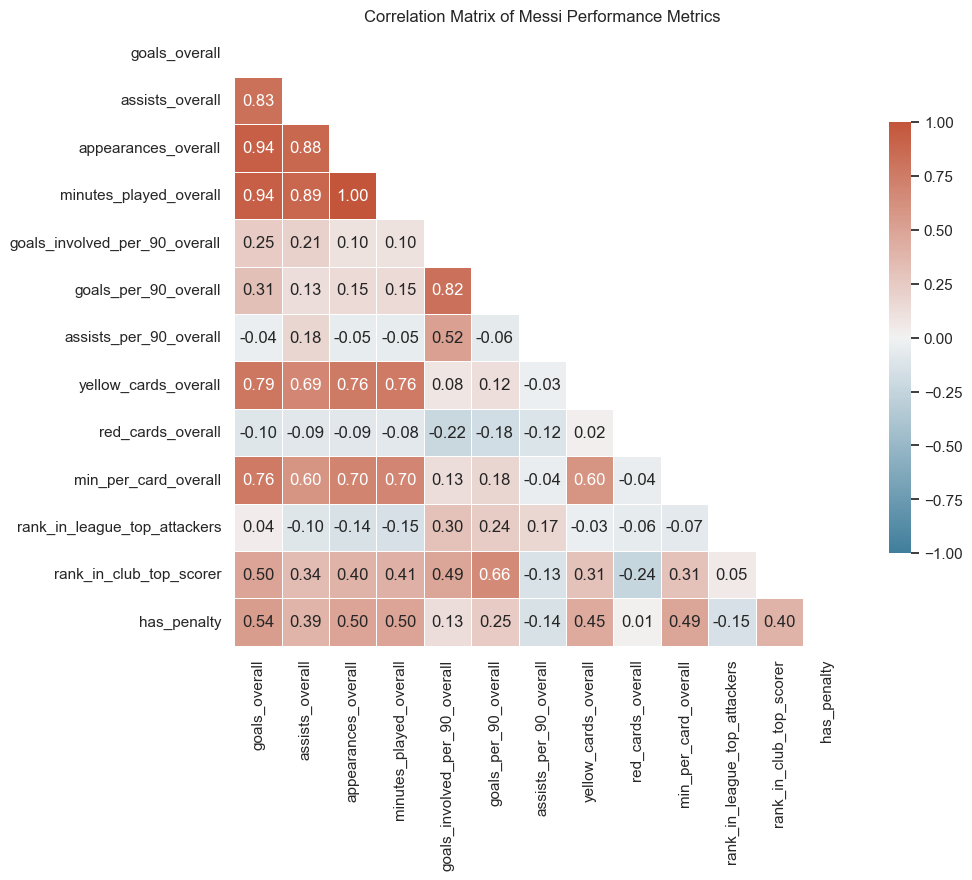

In [14]:
# Select key performance and disciplinary metrics
cols = [
    'goals_overall',
    'assists_overall',
    'appearances_overall',
    'minutes_played_overall',
    'goals_involved_per_90_overall',
    'goals_per_90_overall',
    'assists_per_90_overall',
    'yellow_cards_overall',
    'red_cards_overall',
    'min_per_card_overall',
    'rank_in_league_top_attackers',
    'rank_in_club_top_scorer',
    'has_penalty'
]

subset = detailed_data[cols]

# Compute Pearson correlation matrix
corr_matrix = subset.corr()

# Plot heatmap of correlations
sns.set_theme(style="white")  # Set white theme
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask upper triangle
f, ax = plt.subplots(figsize=(10, 8))

cmap = sns.diverging_palette(230, 20, as_cmap=True)  # Diverging color palette

sns.heatmap(
    corr_matrix,
    mask=mask,           # Show only lower triangle
    cmap=cmap,
    vmax=1,              # Max correlation
    vmin=-1,             # Min correlation
    center=0,
    square=True,
    linewidths=.5,
    annot=True,          # Show correlation values
    fmt=".2f",
    cbar_kws={"shrink": .7}  # Colorbar size
)
plt.title("Correlation Matrix of Messi Performance Metrics")
plt.show()


## Conclusions from matrix

### 1. Appearances and Output Highly Correlated
- The correlation coefficients among `goals_overall`, `assists_overall`, `appearances_overall`, and `minutes_played_overall` are between 0.88–0.99.
- This indicates that the more Messi plays or the more minutes he accumulates, the higher his goals and assists.

### 2. Goals and Assists Move Together
- `goals_overall` and `assists_overall` have a correlation of 0.83.
- This shows Messi’s all-around attacking performance: seasons with more goals often also have more assists.

### 3. Role of Penalties
- `has_penalty` correlates with `goals_overall` at 0.54.
- Correlation with `rank_in_club_top_scorer` is 0.40, indicating that seasons with penalties usually coincide with Messi being the club’s top scorer.

### 4. Discipline Metrics
- `yellow_cards_overall` has medium positive correlations with goals and assists (0.68–0.79) and `red_cards_overall` has almost no correlation with other metrics (around -0.1).



## Statistical test

In [15]:
detailed_data = pd.read_csv('../../data/processed-data/messi_club_detailed_cleaned.csv')

# Numeric variables: continuous data used for calculations, plotting, or modeling
numeric_vars = ['goals_overall', 'assists_overall', 'goals_per_90_overall', 'assists_per_90_overall']

# Binary variables: two possible values (True/False or 0/1)
binary_vars = ['has_penalty']

# Categorical variables: categorical/grouping data, e.g., club name or season
categorical_vars = ['Current Club', 'Season']



### 1. Kolmogorov-Smirnov test

In [16]:
# Kolmogorov-Smirnov test 
print("===== Kolmogorov-Smirnov Test =====")

# Loop through each numeric variable to test for normality
for var in numeric_vars:
    data = detailed_data[var].dropna()              # Remove missing values
    mean = data.mean()                              # Calculate mean
    std = data.std()                                # Calculate standard deviation
    
    # Generate a normal distribution sample with the same mean and std
    normal_sample = np.random.normal(loc=mean, scale=std, size=len(data))
    
    # Perform two-sample KS test: compares data distribution to normal distribution
    ks_stat, p_val = ks_2samp(data, normal_sample)
    
    # Print KS statistic and p-value
    print(f"{var}: KS-stat={ks_stat:.3f}, p-value={p_val:.3f}")

print()


===== Kolmogorov-Smirnov Test =====
goals_overall: KS-stat=0.278, p-value=0.002
assists_overall: KS-stat=0.311, p-value=0.000
goals_per_90_overall: KS-stat=0.178, p-value=0.116
assists_per_90_overall: KS-stat=0.167, p-value=0.164



The test results show that goals_overall and assists_overall per season do not follow a normal distribution, but goals_per_90_overall and assists_per_90_overall can be considered as a normal distribution.

### 2. t-Tests

In [17]:
# t-Tests (Numeric vs Binary)
print("===== t-Tests: Numeric vs Binary =====")
for num_var in numeric_vars:
    for bin_var in binary_vars:
        if bin_var in detailed_data.columns:
            group1 = detailed_data[detailed_data[bin_var]==1][num_var].dropna()
            group2 = detailed_data[detailed_data[bin_var]==0][num_var].dropna()
            t_stat, p_val = ttest_ind(group1, group2, equal_var=False)
            print(f"{num_var} by {bin_var}: t-stat={t_stat:.3f}, p-value={p_val:.3f}")
print()


===== t-Tests: Numeric vs Binary =====
goals_overall by has_penalty: t-stat=5.600, p-value=0.000
assists_overall by has_penalty: t-stat=3.837, p-value=0.000
goals_per_90_overall by has_penalty: t-stat=2.419, p-value=0.018
assists_per_90_overall by has_penalty: t-stat=-1.437, p-value=0.155



The t-test results show that in seasons with penalties, the player’s total goals and assists are higher than that in season without penalty. 

### 3. ANOVA (Numeric vs Categorical)

In [ ]:
# ANOVA (Numeric vs Categorical)
print("===== ANOVA: Numeric vs Categorical =====")
for num_var in numeric_vars:
    for cat_var in categorical_vars:
        if cat_var in detailed_data.columns:
            groups = [group[num_var].dropna() for name, group in detailed_data.groupby(cat_var)]
            if len(groups) > 1:
                f_stat, p_val = f_oneway(*groups)
                print(f"{num_var} across {cat_var}: F-stat={f_stat:.3f}, p-value={p_val:.3f}")

                if p_val < 0.05:
                    tukey = pairwise_tukeyhsd(endog=detailed_data[num_var].dropna(),
                                              groups=detailed_data[cat_var].dropna(),
                                              alpha=0.05)
                    print("Post-hoc Tukey HSD:")
                    print(tukey.summary())
print()

===== ANOVA: Numeric vs Categorical =====
goals_overall across Current Club: F-stat=3.432, p-value=0.021
Post-hoc Tukey HSD:
       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1       group2    meandiff p-adj   lower    upper  reject
-----------------------------------------------------------------
   Argentina FC Barcelona   8.7019 0.0234    0.865 16.5388   True
   Argentina  Inter Miami    3.671 0.8266  -7.5461 14.8881  False
   Argentina          PSG   0.7619 0.9985 -11.7596 13.2834  False
FC Barcelona  Inter Miami  -5.0309 0.5571 -15.0677  5.0059  False
FC Barcelona          PSG    -7.94 0.2745 -19.4161  3.5361  False
 Inter Miami          PSG  -2.9091 0.9478 -16.9129 11.0947  False
-----------------------------------------------------------------
assists_overall across Current Club: F-stat=1.836, p-value=0.147
goals_per_90_overall across Current Club: F-stat=1.890, p-value=0.137
assists_per_90_overall across Current Club: F-stat=1.487, p-value=0.224



The result of ANOVA analysis shows that Messi’s total goals are different across clubs and teams, but only the difference between Argentina and FC Barcelona is significant. For total assists, goals per 90 minutes, and assists per 90 minutes, there are no significant differences between clubs.